<a href="https://colab.research.google.com/github/y-ramakrishna/Zomato_Sales_Analysis/blob/main/Zomato_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/Zomato data .csv')

In [ ]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


 ● The above dataset contain **No null** values

---




In [ ]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [ ]:
df.shape

(148, 7)

● This dataset contains **148** Rows and **7** columns.

In [ ]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0]
    return float(value)
df['rate']=df['rate'].apply(handleRate)
print(df.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type) cost_range  
0                          800          Buffet        Mid  
1                          800          Buffet        Mid  
2                          800          Buffet        Mid  
3                          300          Buffet        Low  
4                          600          Buffet        Mid  


In [ ]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


Text(0.5, 0, 'Type of restaurant')

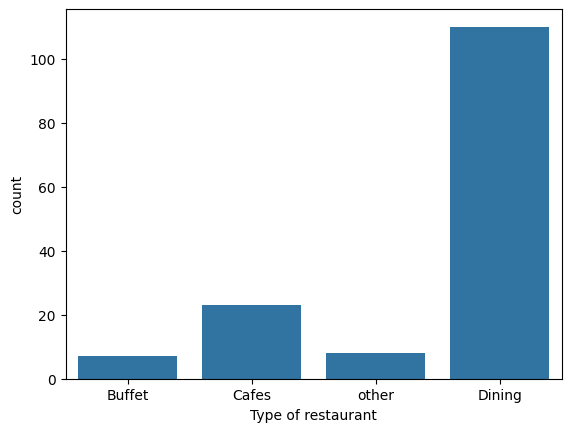

In [ ]:
sns.countplot(x=df["listed_in(type)"])
plt.xlabel('Type of restaurant')

▪ Majority of the restaurant falls under **Dining** category.

---


Text(0.5, 1.0, 'Votes vs Type of restaurant')

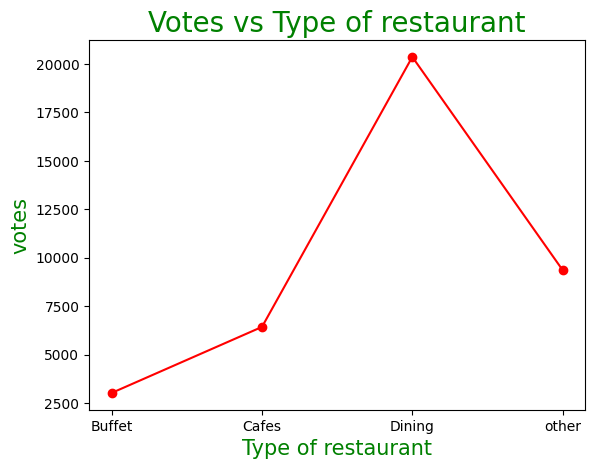

In [ ]:
grouped_data=df.groupby('listed_in(type)')['votes'].sum()
result=pd.DataFrame({'votes': grouped_data})
plt.plot(result,c='red',marker='o')
plt.xlabel('Type of restaurant',c='green',size='15')
plt.ylabel('votes',c='green',size='15')
plt.title('Votes vs Type of restaurant',c='green',size='20')


● In type of restaurant Dining has received maximum votes.

Text(0.5, 1.0, 'Rate distribution')

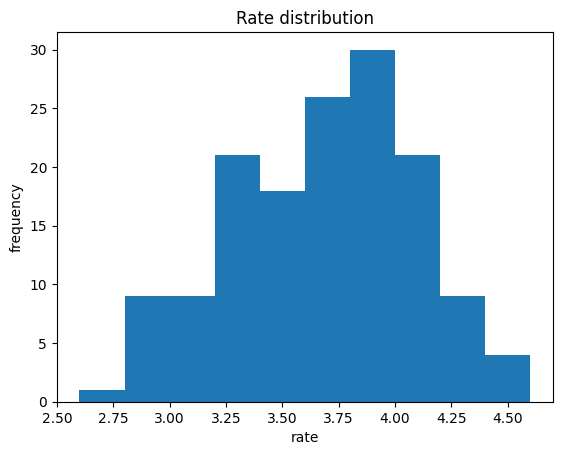

In [ ]:
plt.hist(df['rate'],bins=10)
plt.xlabel('rate')
plt.ylabel('frequency')
plt.title('Rate distribution')

● From above histogram we can say , that majority restaurants received ratings around from 3.5 to 4.

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

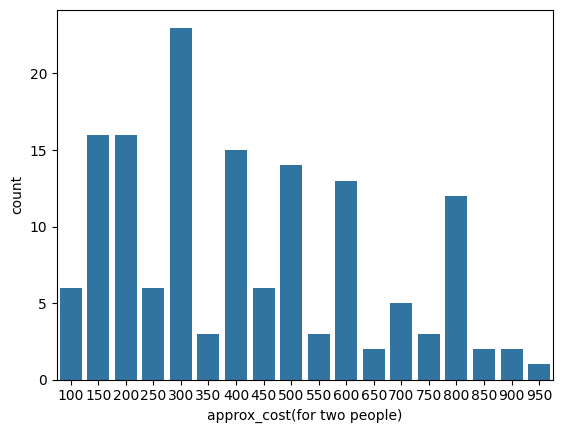

In [ ]:
couple_data=df['approx_cost(for two people)']
sns.countplot(x=couple_data)


● From above countplot ,Majority of couple prefer restaurants with a appropriate cost of 300 rupees.

<Axes: xlabel='online_order', ylabel='rate'>

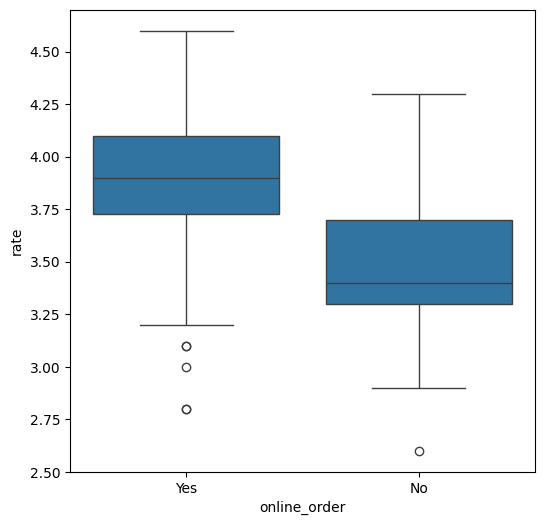

In [ ]:
plt.figure(figsize=(6,6))
sns.boxplot(x ='online_order',y ='rate',data=df)

● Analysis- Offline orders received lower ratings compared to online orders.

<Axes: xlabel='book_table', ylabel='rate'>

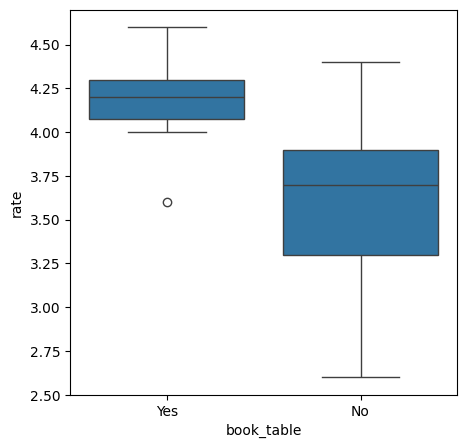

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(x ='book_table',y ='rate',data=df)

●  Book table recevied higher rating compared to walk-in type.

online_order
No     90
Yes    58
Name: count, dtype: int64


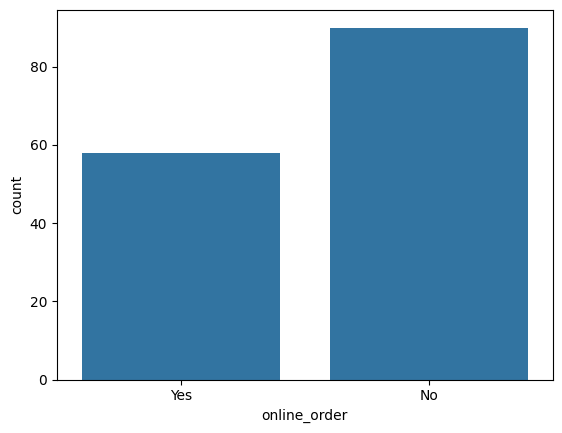

In [ ]:
print(df['online_order'].value_counts())
sns.countplot(x=df['online_order'])
plt.show()

● Most of the people preferred offline orders compared to online orders

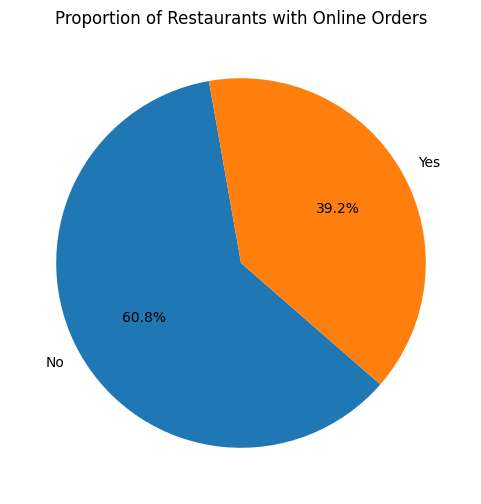

In [ ]:
online_order_counts=df['online_order'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(online_order_counts, labels=online_order_counts.index, autopct='%1.1f%%', startangle=100)
plt.title('Proportion of Restaurants with Online Orders')
plt.show()

In [ ]:
cost_bins = [0, 300, 800, float('inf')]
cost_labels = ['Low', 'Mid', 'High']
df['cost_range'] = pd.cut(df['approx_cost(for two people)'], bins=cost_bins, labels=cost_labels)
print(df[['approx_cost(for two people)', 'cost_range', 'rate']])

     approx_cost(for two people) cost_range  rate
0                            800        Mid   4.1
1                            800        Mid   4.1
2                            800        Mid   3.8
3                            300        Low   3.7
4                            600        Mid   3.8
..                           ...        ...   ...
143                          100        Low   3.3
144                          150        Low   3.3
145                          450        Mid   4.0
146                          800        Mid   3.0
147                          200        Low   3.9

[148 rows x 3 columns]


In [ ]:
avg_ratings = df.groupby('cost_range')['rate'].mean()
print("Average Ratings by Cost Range:")
print(avg_ratings)


Average Ratings by Cost Range:
cost_range
Low     3.528358
Mid     3.726316
High    3.620000
Name: rate, dtype: float64


<ipython-input-83-5577bf93a05e>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_ratings = df.groupby('cost_range')['rate'].mean()


In [ ]:
cost_type_distribution = df.groupby(['cost_range', 'listed_in(type)']).size().reset_index(name='count')
pivot_table = cost_type_distribution.pivot(index='listed_in(type)', columns='cost_range', values='count').fillna(0)
print("Distribution Across 'listed_in(type)' Categories:")
print(pivot_table)


Distribution Across 'listed_in(type)' Categories:
cost_range       Low  Mid  High
listed_in(type)                
Buffet             1    6     0
Cafes              3   19     1
Dining            63   43     4
other              0    8     0


<ipython-input-84-41dfd3886cf5>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cost_type_distribution = df.groupby(['cost_range', 'listed_in(type)']).size().reset_index(name='count')


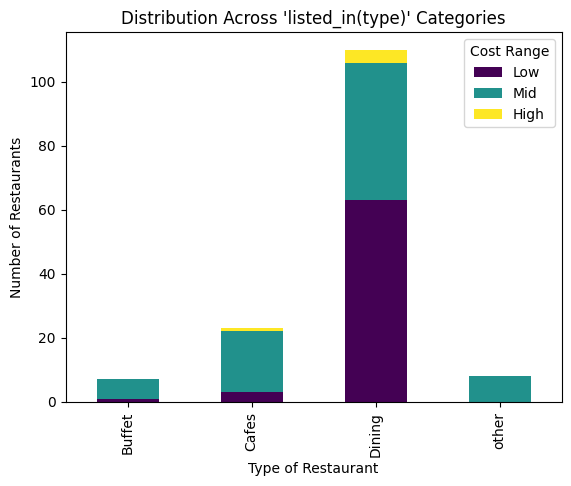

In [ ]:
pivot_table.plot(kind='bar', stacked=True, colormap='viridis')
plt.title("Distribution Across 'listed_in(type)' Categories")
plt.xlabel("Type of Restaurant")
plt.ylabel("Number of Restaurants")
plt.legend(title="Cost Range")
plt.show()


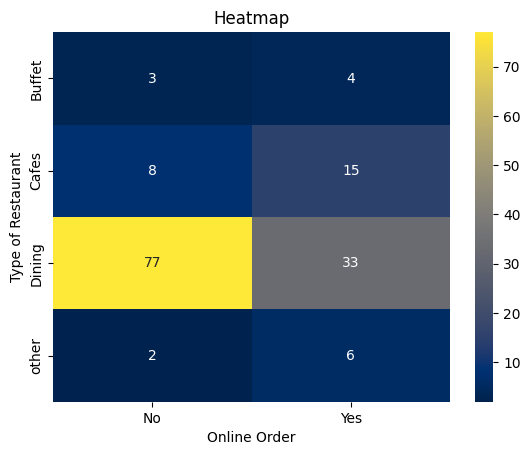

In [ ]:
pivot_table=df.pivot_table(index='listed_in(type)',columns='online_order',values='rate',aggfunc='size')
sns.heatmap(pivot_table,annot=True,cmap="cividis",fmt="d")
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Type of Restaurant')
plt.show()

● Dining restaurants accepts offline orders and where as cafe accepts online orders. This suggests that client prefer orders in person at restaurants ,but  prefers online ordering at cafes
